The purpose of this notebook is to illustrate the detrending procedure for modern observations of methane

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from hydra import compose, initialize
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
)

plt.rcParams.update(matplotlib_rcparams)
fig_width = fig_width_options["two_column_small"]

In [2]:
with initialize(
    version_base=None, config_path="../../../configs"
):  # configs with data paths
    cfg = compose(
        config_name="config",
    )

In [3]:
## import data
path_obs_root = Path(cfg.paths.observations_root)
path_obs_raw = path_obs_root / "raw"
path_obs_detrended = path_obs_root / "cultivated"

obs_conc = pd.read_csv(path_obs_raw / "ch4_annmean_gl.csv", comment="#")
obs_conc_detrended = pd.read_csv(path_obs_detrended / "ch4_modern_detrended.csv")
obs_growth = pd.read_csv(path_obs_raw / "ch4_gr_gl.csv", comment="#")
obs_growth_detrended = pd.read_csv(
    path_obs_detrended / "ch4_growth_modern_detrended.csv"
)

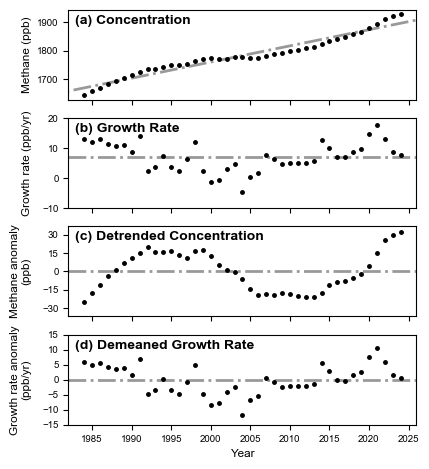

In [5]:
# Create 4-row plot
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(fig_width, fig_width * 1.2))

# 1. Concentration
ax = axes[0]
ax.plot(
    obs_conc["year"],
    obs_conc["mean"],
    color="k",
    marker="o",
    linestyle="None",
    markersize=2.5,
)
# Calculate and plot linear trend
z = np.polyfit(obs_conc["year"], obs_conc["mean"], 1)
p = np.poly1d(z)
years_to_plot = [obs_conc["year"].min() - 5, obs_conc["year"].max() + 5]
ax.plot(years_to_plot, p(years_to_plot), "k", linestyle="-.", linewidth=2, alpha=0.4)
ax.text(
    0.02,
    0.95,
    "(a) Concentration",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
)
ax.set_ylabel("Methane (ppb)")
ax.set_xlim(1982, 2026)

# 2. Growth Rate
ax = axes[1]
ax.plot(
    obs_growth["year"],
    obs_growth["ann inc"],
    color="k",
    marker="o",
    linestyle="None",
    markersize=2.5,
)
mean_growth = obs_growth["ann inc"].mean()
ax.axhline(mean_growth, color="k", linestyle="-.", linewidth=2, alpha=0.4)
ax.text(
    0.02,
    0.95,
    "(b) Growth Rate",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
)
ax.set_ylabel("Growth rate (ppb/yr)")
ax.set_ylim(-10, 20)

# 3. Detrended Concentration
ax = axes[2]
ax.plot(
    obs_conc_detrended["year"],
    obs_conc_detrended["ch4_detrended"],
    color="k",
    marker="o",
    linestyle="None",
    markersize=2.5,
)
ax.axhline(0, color="k", linestyle="-.", linewidth=2, alpha=0.4)
ax.text(
    0.02,
    0.95,
    "(c) Detrended Concentration",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
)
ax.set_ylabel("Methane anomaly\n(ppb)")
ax.set_ylim(-37, 37)
ax.set_yticks(np.arange(-30, 31, 15))

# 4. Demeaned Growth Rate
ax = axes[3]
ax.plot(
    obs_growth_detrended["year"],
    obs_growth_detrended["ch4_growth_detrended"],
    color="k",
    marker="o",
    linestyle="None",
    markersize=2.5,
)
ax.axhline(0, color="k", linestyle="-.", linewidth=2, alpha=0.4)
ax.text(
    0.02,
    0.95,
    "(d) Demeaned Growth Rate",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold",
)
ax.set_ylabel("Growth rate anomaly\n(ppb/yr)")
ax.set_xlabel("Year")
ax.set_ylim(-15, 15)
ax.set_yticks(np.arange(-15, 16, 5))

fig.align_ylabels(axes)

# save figure in pdf format
name = "timeseries_modern"
fig.savefig(
    f"{cfg.paths.figures_dir}/for_publication/supplement/{name}.pdf",
    bbox_inches="tight",
    dpi=200,
)